# Notebook 23 — Object Knowledge Report

## Einstein Object 39

**Object Name:** EIS J033238.61−274631.6

This notebook assembles the astronomical knowledge gathered about Einstein
Object 39 from previous notebooks and external astronomical archives.

The report integrates object identification, catalog information, imaging,
ALMA observations, and scientific context into a single reference document.

---

### Report Sections

1. Object Summary
2. Sky Location
3. Multi-Wavelength Imaging
4. ALMA Observations
5. Astronomical Database Information
6. Scientific Interpretation
7. References

In [1]:
# =========================================================
# Cell 2 — Load Object Information
# =========================================================

from astropy.table import Table
from astropy.coordinates import SkyCoord
import astropy.units as u

catalog_file = "../data/catalogs/einstein_master_catalog.ecsv"
catalog = Table.read(catalog_file, format="ascii.ecsv")

target_id = 39
target = catalog[catalog["label"] == target_id][0]

target_name = "EIS J033238.61-274631.6"
target_type = "Galaxy"
target_z = 0.621743

target_ra = float(target["ra_deg"])
target_dec = float(target["dec_deg"])

target_coord = SkyCoord(
    ra=target_ra * u.deg,
    dec=target_dec * u.deg,
    frame="icrs"
)

In [2]:
# =========================================================
# Cell 3 — Object Summary
# =========================================================

print("=" * 70)
print("Object Summary")
print("=" * 70)
print()

print(f"Einstein Label : {target_id}")
print(f"Object Name    : {target_name}")
print(f"Object Type    : {target_type}")
print()

print(f"Right Ascension: {target_ra:.6f}°")
print(f"Declination    : {target_dec:.6f}°")
print()

print(f"Redshift       : {target_z:.6f}")

Object Summary

Einstein Label : 39
Object Name    : EIS J033238.61-274631.6
Object Type    : Galaxy

Right Ascension: 53.160803°
Declination    : -27.775437°

Redshift       : 0.621743


In [3]:
# =========================================================
# Cell 4 — Sky Coordinates
# =========================================================

print("=" * 70)
print("Sky Coordinates")
print("=" * 70)
print()

print(f"ICRS Right Ascension (deg) : {target_coord.ra.degree:.6f}")
print(f"ICRS Declination (deg)     : {target_coord.dec.degree:.6f}")
print()

print(f"RA  (h:m:s) : {target_coord.ra.to_string(unit=u.hour, sep=':')}")
print(f"Dec (d:m:s) : {target_coord.dec.to_string(sep=':')}")

Sky Coordinates

ICRS Right Ascension (deg) : 53.160803
ICRS Declination (deg)     : -27.775437

RA  (h:m:s) : 3:32:38.59276687
Dec (d:m:s) : -27:46:31.5749912


## Sky Location

Object 39 is located in the southern constellation **Fornax**, within the
GOODS-South / Hubble Ultra Deep Field region.

Its position places it in one of the most intensively observed extragalactic
fields in modern astronomy. Numerous observing programs—including Hubble,
ALMA, JWST, Chandra, Spitzer, and the VLT—have targeted this region, making it
an ideal candidate for multi-wavelength archival research.

### Figure 1 (below) – DSS2 Red Optical Finder Chart

The Digitized Sky Survey 2 (DSS2) Red image provides a wide-field optical view of the region surrounding Einstein Object 39 (EIS J033238.61−274631.6). Although the galaxy is only faintly resolved at the resolution of the DSS2 survey, the image establishes the target's location within its surrounding celestial environment and serves as the starting point for the multi-wavelength investigation.

As the first image in this report, the DSS2 finder chart provides the positional reference needed to compare subsequent observations obtained with the Hubble Space Telescope (HST), the James Webb Space Telescope (JWST), and the Atacama Large Millimeter/submillimeter Array (ALMA). Together, these observations reveal complementary views of the galaxy across optical, infrared, and millimetre wavelengths, allowing a more complete understanding of its physical properties.

Retrieving optical sky image...


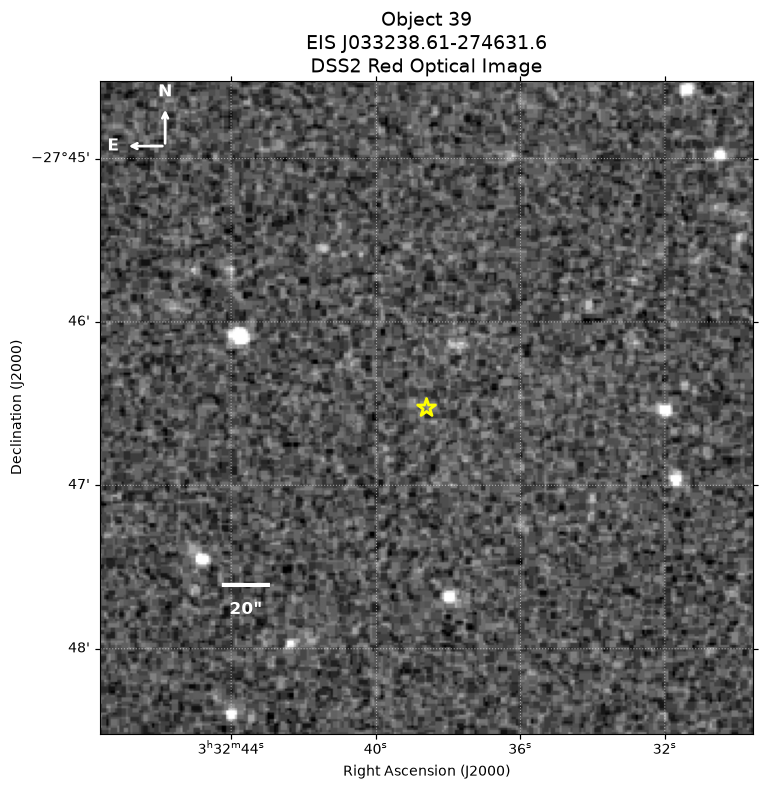

In [4]:
# =========================================================
# Cell 6 — Annotated Sky Image
# =========================================================

from astroquery.skyview import SkyView
from astropy.wcs import WCS
from astropy.visualization import ZScaleInterval
import matplotlib.pyplot as plt
import astropy.units as u

print("Retrieving optical sky image...")

# Download an optical image
images = SkyView.get_images(
    position=target_coord,
    survey=["DSS2 Red"],
    radius=2 * u.arcmin
)

hdu = images[0][0]

wcs = WCS(hdu.header)
image = hdu.data

fig = plt.figure(figsize=(8, 8))
ax = plt.subplot(projection=wcs)

interval = ZScaleInterval()
vmin, vmax = interval.get_limits(image)

ax.imshow(
    image,
    origin="lower",
    cmap="gray",
    vmin=vmin,
    vmax=vmax,
)

# ---------------------------------------------------------
# Mark Object 39
# ---------------------------------------------------------

ax.scatter(
    target_coord.ra.deg,
    target_coord.dec.deg,
    transform=ax.get_transform("world"),
    marker="*",
    s=180,
    edgecolor="yellow",
    facecolor="none",
    linewidth=2,
    label="Object 39"
)

# ---------------------------------------------------------
# North / East indicator
# ---------------------------------------------------------

# Base position in axes coordinates
x0 = 0.10
y0 = 0.90

# North arrow (up)
ax.annotate(
    "",
    xy=(x0, y0 + 0.06),
    xytext=(x0, y0),
    xycoords="axes fraction",
    arrowprops=dict(arrowstyle="->", color="white", lw=2),
)

ax.text(
    x0,
    y0 + 0.07,
    "N",
    transform=ax.transAxes,
    color="white",
    fontsize=12,
    ha="center",
    va="bottom",
    fontweight="bold",
)

# East arrow (left)
ax.annotate(
    "",
    xy=(x0 - 0.06, y0),
    xytext=(x0, y0),
    xycoords="axes fraction",
    arrowprops=dict(arrowstyle="->", color="white", lw=2),
)

ax.text(
    x0 - 0.07,
    y0,
    "E",
    transform=ax.transAxes,
    color="white",
    fontsize=12,
    ha="right",
    va="center",
    fontweight="bold",
)

# ---------------------------------------------------------
# 20 arcsecond scale bar (lower-right)
# ---------------------------------------------------------

from astropy.coordinates import SkyCoord

# Length of scale bar
bar_length = 20 * u.arcsec

# ---------------------------------------------------------
# Position of the scale bar
#
# Positive RA  -> East (left on astronomical images)
# Negative Dec -> South (down)
# ---------------------------------------------------------

bar_center = SkyCoord(
    ra=target_coord.ra + 75*u.arcsec,
    dec=target_coord.dec - 65*u.arcsec,
    frame="icrs"
)

# Endpoints
bar_start = SkyCoord(
    ra=bar_center.ra - bar_length/2,
    dec=bar_center.dec,
    frame="icrs"
)

bar_end = SkyCoord(
    ra=bar_center.ra + bar_length/2,
    dec=bar_center.dec,
    frame="icrs"
)

# Draw scale bar
ax.plot(
    [bar_start.ra.deg, bar_end.ra.deg],
    [bar_start.dec.deg, bar_end.dec.deg],
    transform=ax.get_transform("world"),
    color="white",
    linewidth=3,
    solid_capstyle="butt",
)

# Scale label
ax.text(
    bar_center.ra.deg,
    (bar_center.dec - 6*u.arcsec).deg,
    '20"',
    color="white",
    fontsize=12,
    fontweight="bold",
    ha="center",
    va="top",
    transform=ax.get_transform("world"),
)

# ---------------------------------------------------------
# Grid and labels
# ---------------------------------------------------------

ax.coords.grid(color="white", ls="dotted", alpha=0.5)

ax.set_xlabel("Right Ascension (J2000)")
ax.set_ylabel("Declination (J2000)")

plt.title(
    f"Object {target_id}\n"
    f"{target_name}\n"
    "DSS2 Red Optical Image",
    fontsize=14
)

plt.tight_layout()
plt.show()

**Figure 1.** DSS2 Red optical image of **Einstein Object 39**
(EIS J033238.61−274631.6). The yellow star marks the catalog position of
the target galaxy. Celestial coordinates are shown in the ICRS (J2000)
reference frame.

In [5]:
# =========================================================
# Cell 7 — Search ESASky Maps
# =========================================================

from astroquery.esasky import ESASky
import astropy.units as u

print("Searching ESASky maps...")

maps = ESASky.query_region_maps(
    position=target_coord,
    radius=2*u.arcmin
)

print(f"{len(maps)} map(s) found.")

maps

Searching ESASky maps...
15 map(s) found.


TableList with 15 tables:
	'0:EUCLID-NISP' with 9 column(s) and 6 row(s) 
	'1:EUCLID-VIS' with 9 column(s) and 2 row(s) 
	'2:ALMA' with 28 column(s) and 721 row(s) 
	'3:AKARI' with 11 column(s) and 11 row(s) 
	'4:SPITZER' with 14 column(s) and 20 row(s) 
	'5:HST-OPTICAL' with 17 column(s) and 4688 row(s) 
	'6:HST-UV' with 17 column(s) and 910 row(s) 
	'7:HST-IR' with 17 column(s) and 2937 row(s) 
	'8:HERSCHEL' with 15 column(s) and 437 row(s) 
	'9:JWST-NEAR-IR' with 36 column(s) and 6061 row(s) 
	'10:JWST-MID-IR' with 36 column(s) and 607 row(s) 
	'11:XMM' with 15 column(s) and 38 row(s) 
	'12:XMM-OM-UV' with 17 column(s) and 79 row(s) 
	'13:XMM-OM-OPTICAL' with 17 column(s) and 49 row(s) 
	'14:CHANDRA' with 53 column(s) and 111 row(s) 

In [6]:
hst = maps["HST-OPTICAL"]

print(hst.colnames)

['end_time', 'fov', 'npix', 'observation_oid', 'postcard_url', 'product_url', 'observation_id', 'ra_deg', 'dec_deg', 'target_name', 'instrument_name', 'collection', 'obs_type', 'filter', 'start_time', 'exposure_duration', 'stc_s']


In [7]:
print(hst[:5])

       end_time        ...
         time          ...
---------------------- ...
2012-03-10T03:49:14.48 ...
2012-03-10T01:49:02.48 ...
2012-03-10T02:14:25.49 ...
2012-03-10T03:49:14.48 ...
2012-03-10T11:32:03.48 ...


In [8]:
# =========================================================
# Cell 8
# =========================================================

from astropy.coordinates import SkyCoord

# Extract the HST Optical table
hst = maps["HST-OPTICAL"].copy()

# Coordinates of every HST observation
hst_coord = SkyCoord(
    ra=hst["ra_deg"],
    dec=hst["dec_deg"]
)

# Separation from our target
hst["separation"] = target_coord.separation(hst_coord)

# Sort by separation
hst.sort("separation")

# Show the closest observations
hst[
    "separation",
    "instrument_name",
    "filter",
    "observation_id",
    "exposure_duration",
    "product_url"
][:15]

separation,instrument_name,filter,observation_id,exposure_duration,product_url
deg,,,,seconds,
float64,object,object,object,float64,object
0.0030597895684701566,WFC3,F350LP,hst_12061_h7_wfc3_uvis_total,434.0,https://hst.esac.esa.int/tap-server/data?OBSERVATIONID=hst_12061_h7_wfc3_uvis_total&RETRIEVAL_TYPE=OBSERVATION&CALIBRATION_LEVEL=MAIN&PRODUCTTYPE=SCIENCE&TAPCLIENT=ESASKY
0.0030597895684701566,WFC3,F350LP,hst_12061_h7_wfc3_uvis_f350lp,434.0,https://hst.esac.esa.int/tap-server/data?OBSERVATIONID=hst_12061_h7_wfc3_uvis_f350lp&RETRIEVAL_TYPE=OBSERVATION&CALIBRATION_LEVEL=MAIN&PRODUCTTYPE=SCIENCE&TAPCLIENT=ESASKY
0.003219109594766879,WFC3/UVIS,F350LP,hst_12061_h7_wfc3_uvis_f350lp_ibeuh7tu,434.0,https://hst.esac.esa.int/tap-server/data?OBSERVATIONID=hst_12061_h7_wfc3_uvis_f350lp_ibeuh7tu&RETRIEVAL_TYPE=OBSERVATION&CALIBRATION_LEVEL=MAIN&PRODUCTTYPE=SCIENCE&TAPCLIENT=ESASKY
0.0032215589327631846,WFC3/UVIS,F350LP,hst_12061_h7_wfc3_uvis_f350lp_ibeuh7,434.0,https://hst.esac.esa.int/tap-server/data?OBSERVATIONID=hst_12061_h7_wfc3_uvis_f350lp_ibeuh7&RETRIEVAL_TYPE=OBSERVATION&CALIBRATION_LEVEL=MAIN&PRODUCTTYPE=SCIENCE&TAPCLIENT=ESASKY
0.007325671766157504,WFC3,F336W,hst_12534_3d_wfc3_uvis_total,5890.0,https://hst.esac.esa.int/tap-server/data?OBSERVATIONID=hst_12534_3d_wfc3_uvis_total&RETRIEVAL_TYPE=OBSERVATION&CALIBRATION_LEVEL=MAIN&PRODUCTTYPE=SCIENCE&TAPCLIENT=ESASKY
0.007325671766157504,WFC3,F336W,hst_12534_3d_wfc3_uvis_f336w,5890.0,https://hst.esac.esa.int/tap-server/data?OBSERVATIONID=hst_12534_3d_wfc3_uvis_f336w&RETRIEVAL_TYPE=OBSERVATION&CALIBRATION_LEVEL=MAIN&PRODUCTTYPE=SCIENCE&TAPCLIENT=ESASKY
0.007325717502510042,WFC3,F336W,hst_12534_3e_wfc3_uvis_total,5890.0,https://hst.esac.esa.int/tap-server/data?OBSERVATIONID=hst_12534_3e_wfc3_uvis_total&RETRIEVAL_TYPE=OBSERVATION&CALIBRATION_LEVEL=MAIN&PRODUCTTYPE=SCIENCE&TAPCLIENT=ESASKY
0.007325717502510042,WFC3,F336W,hst_12534_3e_wfc3_uvis_f336w,5890.0,https://hst.esac.esa.int/tap-server/data?OBSERVATIONID=hst_12534_3e_wfc3_uvis_f336w&RETRIEVAL_TYPE=OBSERVATION&CALIBRATION_LEVEL=MAIN&PRODUCTTYPE=SCIENCE&TAPCLIENT=ESASKY


In [9]:
# =========================================================
# Cell 9 — Figure 2: Hubble Observation Summary
# =========================================================

from astropy.table import Table

# Keep only the most useful columns
figure2 = hst[
    "separation",
    "instrument_name",
    "filter",
    "observation_id",
    "exposure_duration"
].copy()

# Convert separation to arcseconds
figure2["separation"] = figure2["separation"].to(u.arcsec)

# Rename columns for publication
figure2.rename_column("separation", "Sep (arcsec)")
figure2.rename_column("instrument_name", "Instrument")
figure2.rename_column("filter", "Filter")
figure2.rename_column("observation_id", "Observation ID")
figure2.rename_column("exposure_duration", "Exposure (s)")

# Display the closest 15 observations
figure2[:15]

Sep (arcsec),Instrument,Filter,Observation ID,Exposure (s)
arcsec,,,,seconds
float64,object,object,object,float64
11.015242446492564,WFC3,F350LP,hst_12061_h7_wfc3_uvis_total,434.0
11.015242446492564,WFC3,F350LP,hst_12061_h7_wfc3_uvis_f350lp,434.0
11.588794541160764,WFC3/UVIS,F350LP,hst_12061_h7_wfc3_uvis_f350lp_ibeuh7tu,434.0
11.597612157947465,WFC3/UVIS,F350LP,hst_12061_h7_wfc3_uvis_f350lp_ibeuh7,434.0
26.372418358167018,WFC3,F336W,hst_12534_3d_wfc3_uvis_total,5890.0
26.372418358167018,WFC3,F336W,hst_12534_3d_wfc3_uvis_f336w,5890.0
26.372583009036152,WFC3,F336W,hst_12534_3e_wfc3_uvis_total,5890.0
26.372583009036152,WFC3,F336W,hst_12534_3e_wfc3_uvis_f336w,5890.0


In [10]:
# =========================================================
# Cell 10 — Select the HST science image for Figure 2
# =========================================================

# Look for the first observation that is NOT a "_total" product.
best = None

for row in hst:
    obsid = str(row["observation_id"])

    if not obsid.endswith("_total"):
        best = row
        break

if best is None:
    raise RuntimeError("No suitable HST science image found.")

print("=" * 70)
print("Selected HST Science Image")
print("=" * 70)

print(f"Observation ID : {best['observation_id']}")
print(f"Instrument     : {best['instrument_name']}")
print(f"Filter         : {best['filter']}")
print(f"Exposure       : {best['exposure_duration']} s")
print(f"Separation     : {best['separation'] * 3600:.2f} arcsec")
print()
print("Product URL:")
print(best["product_url"])

Selected HST Science Image
Observation ID : hst_12061_h7_wfc3_uvis_f350lp
Instrument     : WFC3
Filter         : F350LP
Exposure       : 434.0 s
Separation     : 11.02 arcsec

Product URL:
https://hst.esac.esa.int/tap-server/data?OBSERVATIONID=hst_12061_h7_wfc3_uvis_f350lp&RETRIEVAL_TYPE=OBSERVATION&CALIBRATION_LEVEL=MAIN&PRODUCTTYPE=SCIENCE&TAPCLIENT=ESASKY


In [11]:
# =========================================================
# Cell 11 — Test the HST product URL
# =========================================================

import requests

url = best["product_url"]

print("Contacting ESASky archive...")

response = requests.get(url, allow_redirects=True)

print("\nStatus Code:")
print(response.status_code)

print("\nFinal URL:")
print(response.url)

print("\nContent-Type:")
print(response.headers.get("Content-Type"))

print("\nContent-Disposition:")
print(response.headers.get("Content-Disposition"))

print("\nFirst 200 bytes returned:")
print(response.content[:200])

Contacting ESASky archive...

Status Code:
200

Final URL:
https://hst.esac.esa.int/tap-server/data?OBSERVATIONID=hst_12061_h7_wfc3_uvis_f350lp&RETRIEVAL_TYPE=OBSERVATION&CALIBRATION_LEVEL=MAIN&PRODUCTTYPE=SCIENCE&TAPCLIENT=ESASKY

Content-Type:
application/fits

Content-Disposition:
inline;filename="hst_12061_h7_wfc3_uvis_f350lp_drz.fits.gz"

First 200 bytes returned:
b"\x1f\x8b\x08\x00\x00\x00\x00\x00\x00\x00\xec\xdd}s\xdbF\xa2/\xe8\xfd(\xbcgo\x1d'\xf7X/\xa4,\xcb\xca\xa9\xfcAS\x94\xcd\x89\xde\x86\xa4\x9dd\xb6\xb6T\xb4DY\xbc#\x91\x1a\x92\x8a\xe3\xf9\xf4\xb7\x1b$\xc8\xa6\xdel\x93Hfv\xeby\xaaf\x02Y\xd2O\r\xa0\xd1h\x00\x8df\xabqxrP/\x95~,=\xa0]\xda(\xed\xf7\xc6\xa3\xd2h\xdc\xe9\x9fw\x86\xe7\x0f\xfd\xd0\xa2\xd7\x8d\xf6I\xe3\x97\x87\xf3\xca/C\xde\xeb\x98w\xd3\x1d\x96nz\xbfw\xaf\xbe\x98wT\xfd\xa5\xd1*=R\xbe\xcd\x90wt{\xfd!\xa4\r.J\x9d\xdf\xbb\xa3/\xe6\xd5\x7fi\xd7\x8f\xf6\x9e\\\xdf\xabn\xe9\xba\xf3\xb9t6\xe8\x8f;\xbd~\xa9\xfb\xfb\xb8\xdb\x1f\xf5\x06\xfd\x07\xc3"


In [12]:
# =========================================================
# Cell 12 — Save the HST FITS image
# =========================================================

filename = "figure2_hst_wfc3_f350lp_drz.fits.gz"

with open(filename, "wb") as f:
    f.write(response.content)

print(f"Saved: {filename}")

Saved: figure2_hst_wfc3_f350lp_drz.fits.gz


In [13]:
# =========================================================
# Cell 13 — Inspect the FITS file
# =========================================================

from astropy.io import fits

fits.info(filename)

Filename: figure2_hst_wfc3_f350lp_drz.fits.gz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     838   ()      
  1  SCI           1 ImageHDU        80   (5977, 6009)   float32   
  2  WHT           1 ImageHDU        47   (5977, 6009)   float32   
  3  CTX           1 ImageHDU        42   (5977, 6009)   int32   
  4  HDRTAB        1 BinTableHDU    557   2R x 274C   [9A, 3A, J, D, D, D, D, D, D, D, D, D, D, D, D, J, 11A, 4A, 1A, 4A, 4A, D, D, D, D, 3A, D, D, D, D, D, D, D, D, D, D, D, D, J, J, 8A, 23A, D, D, D, D, J, J, 8A, 23A, 9A, 18A, 4A, J, D, D, D, J, J, J, J, 23A, D, D, D, D, J, J, 4A, 3A, 4A, J, D, D, D, 23A, 1A, J, D, D, D, 4A, 1A, 12A, 12A, 8A, 23A, D, D, 10A, 10A, D, D, D, 4A, 3A, 3A, 4A, 8A, 7A, D, J, D, 6A, 9A, 8A, D, D, 4A, 18A, 3A, J, 6A, 4A, D, 13A, 8A, 4A, 3A, D, D, D, 3A, 1A, D, 23A, D, D, D, 3A, J, 1A, 4A, D, 3A, 6A, D, D, D, D, D, 23A, D, D, D, D, D, 1A, J, J, J, J, D, 3A, J, D, 5A, 7A, D, D, D, D, D, D, D, D, D, D, D, D,

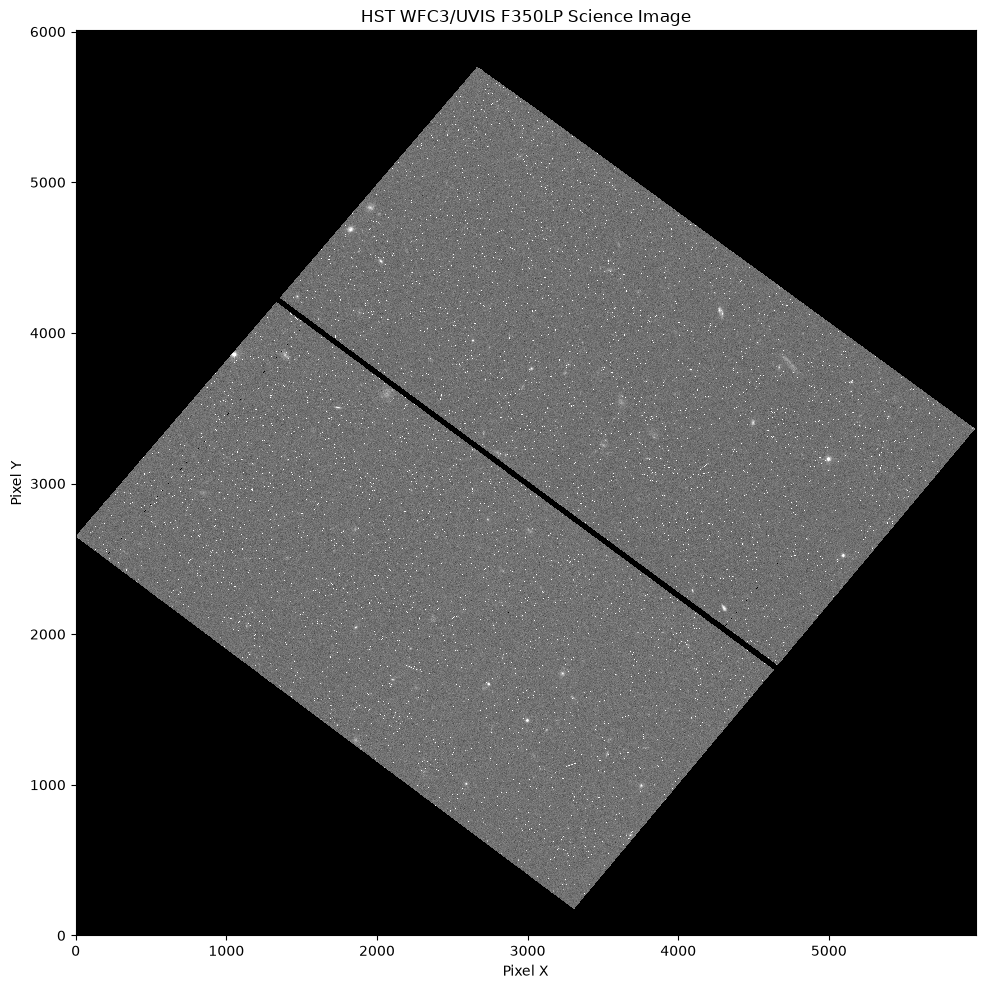

HST Science Image Verification
Filename : figure2_hst_wfc3_f350lp_drz.fits.gz
Image size : 5977 × 6009 pixels
Minimum pixel value : 0.000
Maximum pixel value : 175.379


In [14]:
# =========================================================
# Cell 14 — Verify the HST Science Image
# =========================================================

from astropy.io import fits
import matplotlib.pyplot as plt
from astropy.visualization import simple_norm

# ---------------------------------------------------------
# Open the HST science image
# ---------------------------------------------------------

with fits.open(filename) as hdul:
    image = hdul["SCI"].data

# ---------------------------------------------------------
# Display the full calibrated science image
# ---------------------------------------------------------

norm = simple_norm(
    image,
    stretch="asinh",
    percent=99.5
)

plt.figure(figsize=(10, 10))

plt.imshow(
    image,
    origin="lower",
    cmap="gray",
    norm=norm,
    interpolation="nearest"
)

plt.title("HST WFC3/UVIS F350LP Science Image")
plt.xlabel("Pixel X")
plt.ylabel("Pixel Y")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Report basic image information
# ---------------------------------------------------------

print("=" * 70)
print("HST Science Image Verification")
print("=" * 70)
print(f"Filename : {filename}")
print(f"Image size : {image.shape[1]} × {image.shape[0]} pixels")
print(f"Minimum pixel value : {image.min():.3f}")
print(f"Maximum pixel value : {image.max():.3f}")
print("=" * 70)

### Figure 2 (below) – HST/WFC3 F350LP image of Einstein Object 39 (EIS J033238.61−274631.6). 

The yellow arrow indicates the catalog position of the target galaxy derived from the World Coordinate System (WCS) contained in the calibrated FITS image. The horizontal bar represents an angular scale of 20 arcseconds.

Einstein Object 39
Pixel coordinates : (2799.19, 3208.08)
Saved: figure2_hst_f350lp.png


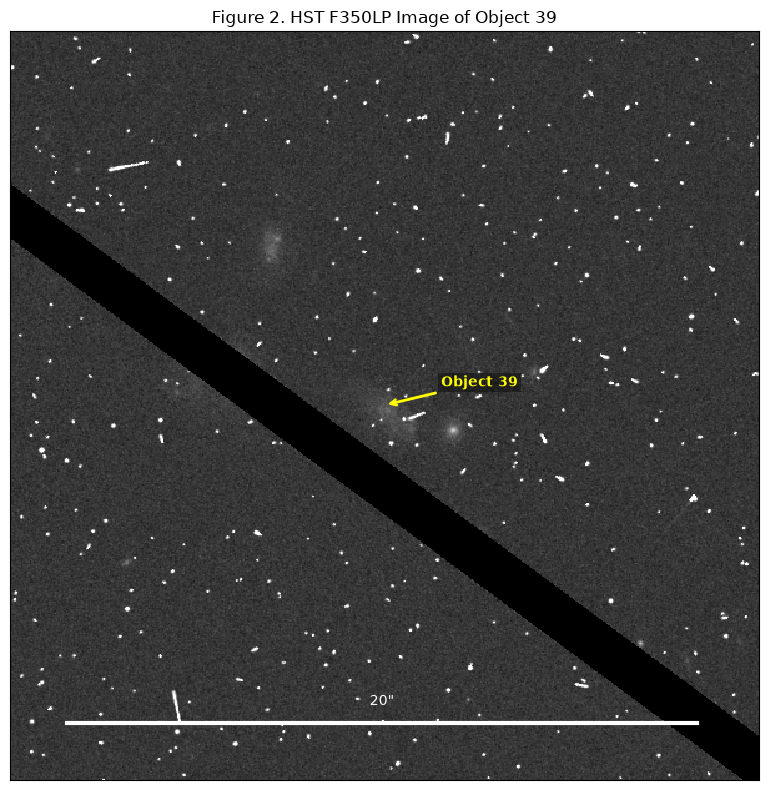

In [15]:
# =========================================================
# Cell 15 — Figure 2
# HST WFC3/UVIS F350LP Image of Einstein Object 39
# =========================================================

from astropy.io import fits
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
from astropy.nddata import Cutout2D
from astropy.visualization import simple_norm
from matplotlib.patches import Circle
import matplotlib.pyplot as plt
import astropy.units as u

# ---------------------------------------------------------
# Open the HST FITS image
# ---------------------------------------------------------

with fits.open(filename) as hdul:
    image = hdul["SCI"].data
    header = hdul["SCI"].header

wcs = WCS(header)

# ---------------------------------------------------------
# Convert the target coordinates to image pixels
# ---------------------------------------------------------

x, y = wcs.world_to_pixel(target_coord)

print("=" * 70)
print("Einstein Object 39")
print("=" * 70)
print(f"Pixel coordinates : ({x:.2f}, {y:.2f})")
print("=" * 70)

# ---------------------------------------------------------
# Create a cutout centred on the target
# ---------------------------------------------------------

cutout_size = (600, 600)          # pixels

cutout = Cutout2D(
    image,
    (x, y),
    cutout_size,
    wcs=wcs
)

# ---------------------------------------------------------
# Image stretch
# ---------------------------------------------------------

norm = simple_norm(
    cutout.data,
    stretch="asinh",
    percent=99.5
)

# ---------------------------------------------------------
# Pixel scale (arcsec/pixel)
# ---------------------------------------------------------

pixel_scale = (
    proj_plane_pixel_scales(wcs)[0] * u.deg
).to(u.arcsec).value

# ---------------------------------------------------------
# Plot the figure
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 8))

ax.imshow(
    cutout.data,
    origin="lower",
    cmap="gray",
    norm=norm,
    interpolation="nearest"
)

# ---------------------------------------------------------
# Annotate Einstein Object 39
# ---------------------------------------------------------

cx = cutout.data.shape[1] / 2
cy = cutout.data.shape[0] / 2

ax.annotate(
    "Object 39",
    xy=(cx, cy),
    xytext=(cx + 45, cy + 15),
    color="yellow",
    fontsize=10,
    fontweight="bold",
    arrowprops=dict(
        arrowstyle="->",
        color="yellow",
        lw=2
    ),
    bbox=dict(
        facecolor="black",
        edgecolor="none",
        alpha=0.40,
        pad=2
    )
)

# ---------------------------------------------------------
# 20 arcsec scale bar
# ---------------------------------------------------------

bar_arcsec = 20.0
bar_pixels = bar_arcsec / pixel_scale

margin = 45

x0 = margin
y0 = margin

ax.plot(
    [x0, x0 + bar_pixels],
    [y0, y0],
    color="white",
    linewidth=3
)

ax.text(
    x0 + bar_pixels / 2,
    y0 + 12,
    '20"',
    color="white",
    ha="center",
    va="bottom",
    fontsize=10
)

# ---------------------------------------------------------
# Final formatting
# ---------------------------------------------------------

ax.set_title(
    "Figure 2. HST F350LP Image of Object 39",
    fontsize=12
)

ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()

# ---------------------------------------------------------
# Optional PNG export
# ---------------------------------------------------------

save_png = True

if save_png:
    outfile = "figure2_hst_f350lp.png"
    plt.savefig(
        outfile,
        dpi=300,
        bbox_inches="tight"
    )
    print(f"Saved: {outfile}")

plt.show()

### Figure 3 – James Webb Space Telescope Imaging

The James Webb Space Telescope (JWST) provides the deepest and highest-resolution infrared view of Einstein Object 39 in this report. Observations at infrared wavelengths penetrate dust more effectively than optical light and are particularly sensitive to the older stellar populations that dominate the mass of distant galaxies. Compared with the DSS2 finder chart and the HST optical image, JWST observations may reveal finer structural details, including the galaxy's morphology, nearby companions, and evidence of interactions or star-forming regions.

The following cells retrieve the calibrated JWST observation from the Mikulski Archive for Space Telescopes (MAST), identify the target within the field using its celestial coordinates, and produce a publication-quality cutout for inclusion in this report.

In [16]:
# ==============================================================
# Cell 17 — Query the MAST Archive for JWST Observations
# ==============================================================

from astroquery.mast import Observations
from astropy.coordinates import SkyCoord
import astropy.units as u

# --------------------------------------------------------------
# Target coordinates
# --------------------------------------------------------------

target_name = "EIS J033238.61-274631.6"

ra = 53.160803
dec = -27.775437

coord = SkyCoord(ra=ra*u.deg,
                 dec=dec*u.deg,
                 frame="icrs")

# --------------------------------------------------------------
# Search radius
# --------------------------------------------------------------

search_radius = 10 * u.arcsec

print(f"Searching the MAST archive for JWST observations of {target_name}...")
print()

# --------------------------------------------------------------
# Query MAST
# --------------------------------------------------------------

obs_table = Observations.query_region(
    coord,
    radius=search_radius
)

# --------------------------------------------------------------
# Keep only JWST observations
# --------------------------------------------------------------

jwst_obs = obs_table[obs_table["obs_collection"] == "JWST"]

print(f"Number of JWST observations found: {len(jwst_obs)}")
print()

if len(jwst_obs) > 0:
    display(
        jwst_obs[
            "obsid",
            "target_name",
            "instrument_name",
            "filters",
            "t_min",
            "proposal_id"
        ]
    )
else:
    print("No JWST observations were found within the search radius.")

Searching the MAST archive for JWST observations of EIS J033238.61-274631.6...

Number of JWST observations found: 694



obsid,target_name,instrument_name,filters,t_min,proposal_id
str9,str47,str13,str18,float64,str135
224250360,POINTINGTHREE-B,NIRCAM/IMAGE,F090W,60220.12378902778,1180
224008668,POINTINGTHREE-B,NIRCAM/IMAGE,F115W,60220.280739988426,1180
224250361,POINTINGTHREE-B,NIRCAM/IMAGE,F150W,60220.59315079861,1180
224008605,POINTINGTHREE-B,NIRCAM/IMAGE,F200W,60220.74922990741,1180
224906793,POINTINGTHREE-B,NIRCAM/IMAGE,F277W,60220.280739988426,1180
224250357,POINTINGTHREE-B,NIRCAM/IMAGE,F335M,60220.12378976852,1180
224906792,POINTINGTHREE-B,NIRCAM/IMAGE,F356W,60220.43756650463,1180
224250358,POINTINGTHREE-B,NIRCAM/IMAGE,F410M,60220.74923064815,1180
224008637,POINTINGTHREE-B,NIRCAM/IMAGE,F444W,60220.59315079861,1180


In [17]:
# ==============================================================
# Cell 18 — Summarize the Available JWST Imaging Observations
# ==============================================================

from astropy.table import unique

# Keep only imaging observations
image_obs = jwst_obs[jwst_obs["dataproduct_type"] == "image"]

print(f"Number of JWST imaging observations: {len(image_obs)}")
print()

# Display one row per observation/filter combination
summary = unique(
    image_obs[
        "proposal_id",
        "target_name",
        "instrument_name",
        "filters",
        "obsid"
    ],
    keys=["proposal_id", "instrument_name", "filters"]
)

summary.sort(["proposal_id", "instrument_name", "filters"])

display(summary)

Number of JWST imaging observations: 438



proposal_id,target_name,instrument_name,filters,obsid
str135,str47,str13,str18,str9
1180,POINTINGTHREE-B,NIRCAM/IMAGE,F090W,224250360
1180,POINTINGTHREE-B,NIRCAM/IMAGE,F115W,224008668
1180,POINTINGTHREE-B,NIRCAM/IMAGE,F150W,224250361
1180,POINTINGTHREE-B,NIRCAM/IMAGE,F200W,224008605
1180,POINTINGTHREE-B,NIRCAM/IMAGE,F277W,224906793
1180,POINTINGTHREE-B,NIRCAM/IMAGE,F335M,224250357
1180,POINTINGTHREE-B,NIRCAM/IMAGE,F356W,224906792
1180,POINTINGTHREE-B,NIRCAM/IMAGE,F410M,224250358
1180,POINTINGTHREE-B,NIRCAM/IMAGE,F444W,224008637


In [18]:
# ==============================================================
# Cell 19 — Retrieve the JWST Science Products
# ==============================================================

from astroquery.mast import Observations

# --------------------------------------------------------------
# Selected observation
# --------------------------------------------------------------

obsid = "224008605"      # Proposal 1180
filter_name = "F200W"

print(f"Selected Observation ID : {obsid}")
print(f"Filter                 : {filter_name}")
print()

# --------------------------------------------------------------
# Obtain the available products
# --------------------------------------------------------------

products = Observations.get_product_list(obsid)

print(f"Number of products: {len(products)}")
print()

display(
    products[
        "productFilename",
        "productType",
        "calib_level",
        "dataURI",
        "size"
    ]
)

Selected Observation ID : 224008605
Filter                 : F200W

Number of products: 1158



productFilename,productType,calib_level,dataURI,size
str50,str9,int64,str68,int64
jw01180013001_10101_00006_nrca1_trapsfilled.fits,AUXILIARY,2,mast:JWST/product/jw01180013001_10101_00006_nrca1_trapsfilled.fits,50365440
jw01180-o013_20260625t233125_image2_00049_asn.json,INFO,2,mast:JWST/product/jw01180-o013_20260625t233125_image2_00049_asn.json,1803
jw01180_20260625t233125_pool.csv,INFO,2,mast:JWST/product/jw01180_20260625t233125_pool.csv,3751640
jw01180013001_10101_00006_nrca1_uncal.jpg,PREVIEW,1,mast:JWST/product/jw01180013001_10101_00006_nrca1_uncal.jpg,563174
jw01180013001_10101_00006_nrca1_cal.jpg,PREVIEW,2,mast:JWST/product/jw01180013001_10101_00006_nrca1_cal.jpg,1200430
jw01180013001_10101_00006_nrca1_i2d.jpg,PREVIEW,2,mast:JWST/product/jw01180013001_10101_00006_nrca1_i2d.jpg,1025126
jw01180013001_10101_00006_nrca1_o013_crf.jpg,PREVIEW,2,mast:JWST/product/jw01180013001_10101_00006_nrca1_o013_crf.jpg,1207470
jw01180013001_10101_00006_nrca1_rate.jpg,PREVIEW,2,mast:JWST/product/jw01180013001_10101_00006_nrca1_rate.jpg,1106785
jw01180013001_10101_00006_nrca1_rateints.jpg,PREVIEW,2,mast:JWST/product/jw01180013001_10101_00006_nrca1_rateints.jpg,1106785


In [19]:
# ==============================================================
# Cell 20 — Download the Selected JWST Mosaic
# ==============================================================

from astroquery.mast import Observations

# --------------------------------------------------------------
# Select the final science product
# --------------------------------------------------------------

filename = "jw01180-o013_t011_nircam_clear-f200w_i2d.fits"

product = products[
    products["productFilename"] == filename
]

print("Downloading:")
print(filename)
print()

download_manifest = Observations.download_products(
    product,
    mrp_only=False
)

display(download_manifest)

Downloading:
jw01180-o013_t011_nircam_clear-f200w_i2d.fits

INFO: Found cached file ./mastDownload/JWST/jw01180-o013_t011_nircam_clear-f200w/jw01180-o013_t011_nircam_clear-f200w_i2d.fits with expected size 1626350400. [astroquery.query]


Local Path,Status,Message,URL
str102,str8,object,object
./mastDownload/JWST/jw01180-o013_t011_nircam_clear-f200w/jw01180-o013_t011_nircam_clear-f200w_i2d.fits,COMPLETE,None,None


In [20]:
# ==============================================================
# Cell 21 — Locate the Downloaded FITS File
# ==============================================================

from pathlib import Path

fits_files = list(Path("mastDownload").rglob("*f200w_i2d.fits"))

print(f"Found {len(fits_files)} FITS file(s):")
print()

for f in fits_files:
    print(f)

Found 1 FITS file(s):

mastDownload/JWST/jw01180-o013_t011_nircam_clear-f200w/jw01180-o013_t011_nircam_clear-f200w_i2d.fits


In [21]:
# ==============================================================
# Cell 22 — Inspect the JWST FITS File
# ==============================================================

from astropy.io import fits

fits_file = (
    "mastDownload/JWST/"
    "jw01180-o013_t011_nircam_clear-f200w/"
    "jw01180-o013_t011_nircam_clear-f200w_i2d.fits"
)

fits.info(fits_file)

Filename: mastDownload/JWST/jw01180-o013_t011_nircam_clear-f200w/jw01180-o013_t011_nircam_clear-f200w_i2d.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     283   ()      
  1  SCI           1 ImageHDU        75   (10009, 4512)   float32   
  2  ERR           1 ImageHDU        10   (10009, 4512)   float32   
  3  CON           1 ImageHDU        10   (10009, 4512, 3)   int32   
  4  WHT           1 ImageHDU         9   (10009, 4512)   float32   
  5  VAR_POISSON    1 ImageHDU         9   (10009, 4512)   float32   
  6  VAR_RNOISE    1 ImageHDU         9   (10009, 4512)   float32   
  7  VAR_FLAT      1 ImageHDU         9   (10009, 4512)   float32   
  8  HDRTAB        1 BinTableHDU    542   72R x 266C   [23A, 5A, 3A, 45A, 7A, 13A, 3A, 5A, 5A, 7A, 10A, 4A, L, D, D, 32A, 50A, 62A, 21A, 3A, 20A, 10A, 12A, 23A, 23A, 26A, 11A, 5A, 3A, 3A, 2A, 1A, 2A, 1A, L, 14A, 22A, 2A, 26A, 20A, 27A, 10A, K, L, L, L, L, 15A, 15A, 5A, D, D, D, D, D, D, 27A

In [22]:
# ==============================================================
# Cell 23 — Open the JWST Science Image
# ==============================================================

from astropy.io import fits
from astropy.wcs import WCS

fits_file = (
    "mastDownload/JWST/"
    "jw01180-o013_t011_nircam_clear-f200w/"
    "jw01180-o013_t011_nircam_clear-f200w_i2d.fits"
)

# --------------------------------------------------------------
# Read the science extension
# --------------------------------------------------------------

with fits.open(fits_file) as hdul:

    image = hdul["SCI"].data
    header = hdul["SCI"].header

wcs = WCS(header)

print("JWST Science Image")
print("------------------")
print(f"Image shape : {image.shape}")
print(f"Data type   : {image.dtype}")

JWST Science Image
------------------
Image shape : (4512, 10009)
Data type   : >f4


Set DATE-AVG to '2023-10-03T19:48:07.188' from MJD-AVG.
Set DATE-END to '2023-10-03T21:37:33.999' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    20.589899 from OBSGEO-[XYZ].
Set OBSGEO-H to 1231318776.096 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [23]:
# ==============================================================
# Cell 24 — Verify the JWST WCS
# ==============================================================

from astropy.coordinates import SkyCoord
import astropy.units as u

target = SkyCoord(
    ra=53.160803 * u.deg,
    dec=-27.775437 * u.deg,
    frame="icrs"
)

x, y = wcs.world_to_pixel(target)

print(f"Target pixel coordinates:")
print(f"    x = {x:.2f}")
print(f"    y = {y:.2f}")

print()
print(f"Image width  = {image.shape[1]}")
print(f"Image height = {image.shape[0]}")

if 0 <= x < image.shape[1] and 0 <= y < image.shape[0]:
    print("\n✓ Target lies inside the JWST mosaic.")
else:
    print("\n⚠ Target is outside the image boundaries.")

Target pixel coordinates:
    x = 3260.38
    y = 873.70

Image width  = 10009
Image height = 4512

✓ Target lies inside the JWST mosaic.


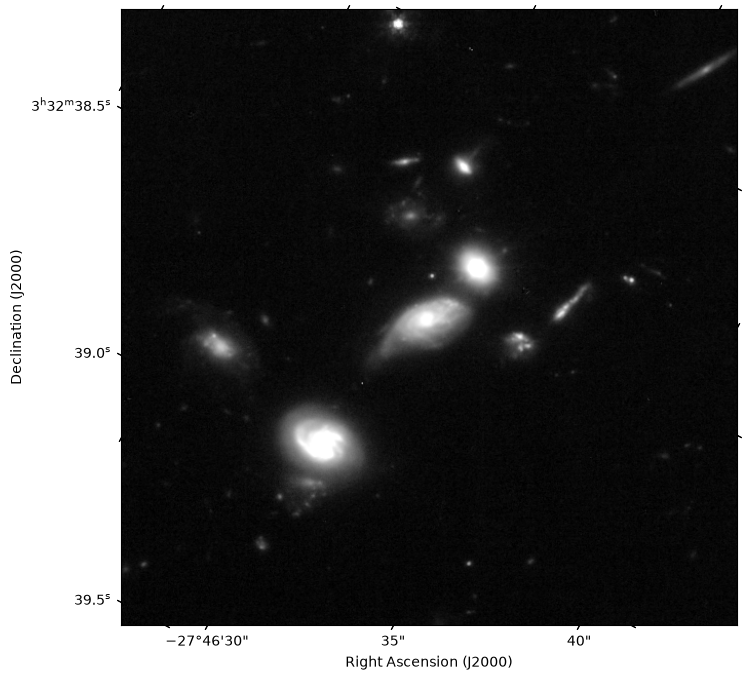

In [24]:
# ==============================================================
# Cell 25 — Create a JWST Cutout
# ==============================================================

from astropy.nddata import Cutout2D
from astropy.visualization import simple_norm
import matplotlib.pyplot as plt

# --------------------------------------------------------------
# Create a 600×600 pixel cutout
# --------------------------------------------------------------

size = (600, 600)

cutout = Cutout2D(
    image,
    position=(x, y),
    size=size,
    wcs=wcs
)

fig = plt.figure(figsize=(8, 8))

ax = plt.subplot(projection=cutout.wcs)

norm = simple_norm(
    cutout.data,
    stretch="asinh",
    percent=99.5
)

ax.imshow(
    cutout.data,
    origin="lower",
    cmap="gray",
    norm=norm
)

ax.set_xlabel("Right Ascension (J2000)")
ax.set_ylabel("Declination (J2000)")

plt.show()

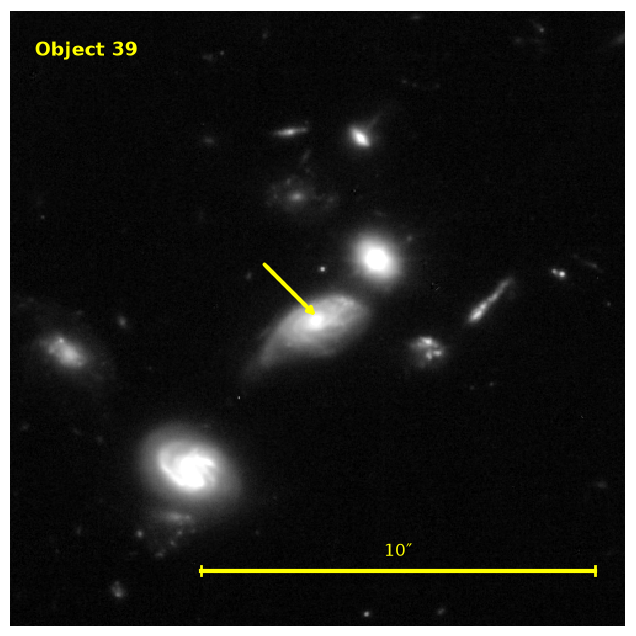

✓ Saved figure3_jwst_f200w_clean.png
✓ Saved figure3_jwst_f200w.png


In [25]:
# ==============================================================
# Cell 25 — Figure 3
# JWST/NIRCam F200W Publication Figure
#
# Produces:
#   figure3_jwst_f200w_clean.png
#   figure3_jwst_f200w.png
# ==============================================================

from astropy.io import fits
from astropy.wcs import WCS, FITSFixedWarning
from astropy.coordinates import SkyCoord
from astropy.visualization import simple_norm
from astropy.wcs.utils import proj_plane_pixel_scales

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.simplefilter("ignore", FITSFixedWarning)

# Output files
clean_filename = "figure3_jwst_f200w_clean.png"
annotated_filename = "figure3_jwst_f200w.png"

# ==============================================================
# Open JWST image
# ==============================================================

fits_file = (
    "mastDownload/JWST/"
    "jw01180-o013_t011_nircam_clear-f200w/"
    "jw01180-o013_t011_nircam_clear-f200w_i2d.fits"
)

with fits.open(fits_file) as hdul:

    image = hdul["SCI"].data
    header = hdul["SCI"].header

science_wcs = WCS(header)

# ==============================================================
# Object coordinates
# ==============================================================

target = SkyCoord(
    ra=53.160803*u.deg,
    dec=-27.775437*u.deg,
    frame="icrs"
)

target_x, target_y = science_wcs.world_to_pixel(target)

target_x = float(np.asarray(target_x))
target_y = float(np.asarray(target_y))

# ==============================================================
# Build 500×500 cutout
# ==============================================================

half_size = 250

x_center = int(round(target_x))
y_center = int(round(target_y))

cutout = image[
    y_center-half_size:y_center+half_size,
    x_center-half_size:x_center+half_size
]

height, width = cutout.shape

# ==============================================================
# Display stretch
# ==============================================================

norm = simple_norm(
    cutout,
    stretch="asinh",
    percent=99.5
)

# ==============================================================
# Helper function
# ==============================================================

def setup_axes(ax):

    ax.imshow(
        cutout,
        origin="lower",
        cmap="gray",
        norm=norm,
        interpolation="nearest"
    )

    ax.set_xlim(0, width)
    ax.set_ylim(0, height)
    ax.set_aspect("equal")
    ax.set_axis_off()

# ==============================================================
# Figure A
# Clean version
# ==============================================================

fig_clean, ax_clean = plt.subplots(figsize=(8,8))

setup_axes(ax_clean)

fig_clean.savefig(
    "figure3_jwst_f200w_clean.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.close(fig_clean)

# ==============================================================
# Figure B
# Annotated version
# ==============================================================

fig, ax = plt.subplots(figsize=(8,8))

setup_axes(ax)

# --------------------------------------------------------------
# Arrow
# --------------------------------------------------------------

object_x = half_size
object_y = half_size

ax.annotate(
    "",
    xy=(object_x, object_y),
    xytext=(object_x-45, object_y+45),
    arrowprops=dict(
        arrowstyle="->",
        color="yellow",
        lw=3
    )
)

# --------------------------------------------------------------
# Object label
# --------------------------------------------------------------

ax.text(
    0.04,
    0.95,
    "Object 39",
    transform=ax.transAxes,
    fontsize=14,
    fontweight="bold",
    color="yellow",
    ha="left",
    va="top"
)

# --------------------------------------------------------------
# Scale bar
# --------------------------------------------------------------

pixel_scale = proj_plane_pixel_scales(science_wcs)[0] * 3600.0

bar_arcsec = 10.0
bar_pixels = bar_arcsec / pixel_scale

margin = 25

bar_x1 = width - margin - bar_pixels
bar_x2 = width - margin
bar_y = 45

ax.plot(
    [bar_x1, bar_x2],
    [bar_y, bar_y],
    color="yellow",
    lw=3
)

tick = 4

ax.plot(
    [bar_x1, bar_x1],
    [bar_y-tick, bar_y+tick],
    color="yellow",
    lw=2
)

ax.plot(
    [bar_x2, bar_x2],
    [bar_y-tick, bar_y+tick],
    color="yellow",
    lw=2
)

ax.text(
    (bar_x1+bar_x2)/2,
    bar_y+12,
    "10″",
    color="yellow",
    fontsize=12,
    ha="center"
)

# ==============================================================
# Save annotated figure
# ==============================================================

fig.savefig(
    annotated_filename,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close(fig)

print(f"✓ Saved {clean_filename}")
print(f"✓ Saved {annotated_filename}")